# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [7]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
import numpy as np
import torch

#!git clone https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git
REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"
CODE_DIR = os.path.join(REPO_ROOT, "code")

# Tell Python where data.py, model.py, train.py, etc. are
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

# Work from the repo root
os.chdir(REPO_ROOT)

OUT_DIR = "/content/submission_2A202602819"

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

if device == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

Using device: cuda
PyTorch version: 2.11.0+cu130
GPU name: Tesla T4


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [8]:
## Part 0 — Dữ liệu

# 1. Create data/processed/train.npz and eval.npz
subprocess.run(
    [sys.executable, "scripts/split_data.py"],
    cwd=REPO_ROOT,
    check=True,
)

# 2. Load, split, standardize, and move data to device
data = prepare_data(
    device,
    val_fraction=0.2,
    seed=42,
    processed_dir=f"{REPO_ROOT}/data/processed",
)

# 3. Get the prepared tensors
X_tr = data["X_tr"]
y_tr = data["y_tr"]

X_val = data["X_val"]
y_val = data["y_val"]

X_eval = data["X_eval"]
y_eval = data["y_eval"]

# 4. Print dataset sizes
print("\nDataset sizes:")
print(f"X_tr   : {X_tr.shape}")
print(f"X_val  : {X_val.shape}")
print(f"X_eval : {X_eval.shape}")

# 5. Check standardization of the 10 numerical columns on X_tr
train_mean = X_tr[:, :10].mean(dim=0)
train_std = X_tr[:, :10].std(dim=0, unbiased=False)

print("\nX_tr numerical-feature means:")
print(train_mean)

print("\nX_tr numerical-feature standard deviations:")
print(train_std)

print("\nMean approximately 0:")
print(torch.allclose(
    train_mean,
    torch.zeros_like(train_mean),
    atol=1e-5,
))

print("Std approximately 1:")
print(torch.allclose(
    train_std,
    torch.ones_like(train_std),
    atol=1e-2,
))

X_tr   : (371847, 54)
y_tr   : (371847,)
X_val  : (92962, 54)
y_val  : (92962,)
X_eval : (116203, 54)
y_eval : (116203,)
Majority-class baseline on val: 0.4876 (class 1)

Dataset sizes:
X_tr   : torch.Size([371847, 54])
X_val  : torch.Size([92962, 54])
X_eval : torch.Size([116203, 54])

X_tr numerical-feature means:
tensor([-4.1035e-11, -4.1035e-10, -2.5442e-09,  4.9242e-10, -2.7494e-09,
        -3.6932e-10, -1.7235e-09, -3.1187e-09, -1.6414e-09,  1.5183e-09],
       device='cuda:0')

X_tr numerical-feature standard deviations:
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000], device='cuda:0')

Mean approximately 0:
True
Std approximately 1:
True


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

Model:
MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)

Number of parameters: 47879
Parameter count check: PASS

Input shape : torch.Size([8, 54])
Logits shape: torch.Size([8, 7])
Forward shape check: PASS

Step-0 validation results:
  loss     = 2.198418
  accuracy = 0.081356
  macro-F1 = 0.048090
  ln(7)    = 1.945910

Nhận xét: Step-0 loss lệch đáng kể khỏi ln(7); cần kiểm tra initialization/model/loss.
Overfit step   0: loss = 1.93856847
Overfit step  50: loss = 0.00014653
Overfit step 100: loss = 0.00007533
Overfit step 150: loss = 0.00006464
Overfit step 200: loss = 0.00005728
Overfit step 250: loss = 0.00005152
Overfit step 300: loss = 0.00004694
Overfit step 350: loss = 0.00004306
Overfit step 400: loss = 0.00003983
Overfit step 450: loss = 0.00003707
Overfit step 499: loss = 0.0000

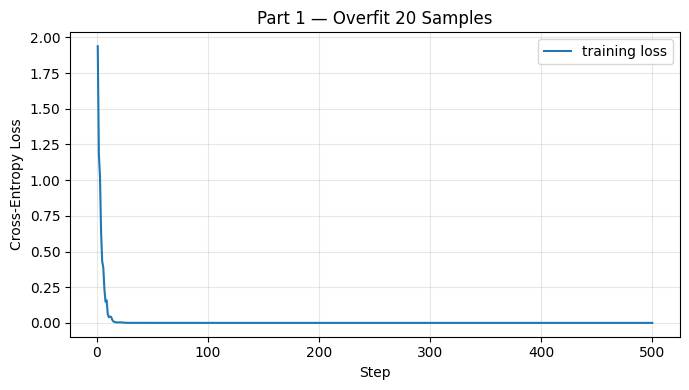


Overfit check: loss decreased = True
Overfit check: PASS — loss đã về gần 0.

Gradient check:
Loss = 1.99469292

net.0.weight                   grad_norm = 0.7968270779
net.0.bias                     grad_norm = 0.3210732639
net.2.weight                   grad_norm = 2.5372698307
net.2.bias                     grad_norm = 0.4425420165
net.4.weight                   grad_norm = 2.0010623932
net.4.bias                     grad_norm = 0.5274041891

Gradient check: PASS


In [9]:
# ============================================================
# PART 1 — XÂY DỰNG MODEL VÀ KIỂM TRA "SỨC KHỎE" BAN ĐẦU
# ============================================================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from model import MLP, EXPECTED_PARAMS, count_params
from train import evaluate


# ------------------------------------------------------------
# Tạo M-base và kiểm tra số tham số
# ------------------------------------------------------------

model = MLP(
    hidden=(256, 128),
    dropout=0.0,
    init="he",
).to(device)

n_params = count_params(model)

print("Model:")
print(model)
print()
print("Number of parameters:", n_params)

assert n_params == EXPECTED_PARAMS[(256, 128)]

print("Parameter count check: PASS")


# ------------------------------------------------------------
# Forward với một batch ngẫu nhiên (8, 54)
# ------------------------------------------------------------

x_random = torch.randn(
    8,
    54,
    device=device,
)

model.eval()

with torch.no_grad():
    logits = model(x_random)

print()
print("Input shape :", x_random.shape)
print("Logits shape:", logits.shape)

assert logits.shape == (8, 7)

print("Forward shape check: PASS")


# ------------------------------------------------------------
# Step-0 loss trên validation
# ------------------------------------------------------------

step0_result = evaluate(
    model,
    data["X_val"],
    data["y_val"],
    loss_name="ce",
)

step0_loss = step0_result["loss"]
step0_acc = step0_result["acc"]
step0_f1 = step0_result["macro_f1"]

ln7 = torch.log(torch.tensor(7.0)).item()

print()
print("Step-0 validation results:")
print(f"  loss     = {step0_loss:.6f}")
print(f"  accuracy = {step0_acc:.6f}")
print(f"  macro-F1 = {step0_f1:.6f}")
print(f"  ln(7)    = {ln7:.6f}")

print()
if abs(step0_loss - ln7) < 0.1:
    print("Nhận xét: Step-0 loss gần ln(7), phù hợp với mô hình khởi tạo ban đầu.")
else:
    print("Nhận xét: Step-0 loss lệch đáng kể khỏi ln(7); cần kiểm tra initialization/model/loss.")


# ------------------------------------------------------------
# Overfit 20 mẫu
# ------------------------------------------------------------

# Lấy 20 mẫu cố định từ training set
X_tiny = data["X_tr"][:20]
y_tiny = data["y_tr"][:20]

# Model mới, dropout tắt
tiny_model = MLP(
    hidden=(256, 128),
    dropout=0.0,
    init="he",
).to(device)

tiny_optimizer = torch.optim.SGD(
    tiny_model.parameters(),
    lr=0.1,
    momentum=0.9,
)

tiny_losses = []

n_steps = 500

for step in range(n_steps):

    tiny_model.train()

    logits = tiny_model(X_tiny)

    loss = F.cross_entropy(
        logits,
        y_tiny,
    )

    tiny_optimizer.zero_grad(set_to_none=True)

    loss.backward()

    tiny_optimizer.step()

    loss_value = loss.item()
    tiny_losses.append(loss_value)

    if step % 50 == 0 or step == n_steps - 1:
        print(
            f"Overfit step {step:3d}: "
            f"loss = {loss_value:.8f}"
        )

print()
print(f"Overfit initial loss: {tiny_losses[0]:.8f}")
print(f"Overfit final loss  : {tiny_losses[-1]:.8f}")


# Vẽ đường cong loss
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, n_steps + 1),
    tiny_losses,
    label="training loss",
)

plt.xlabel("Step")
plt.ylabel("Cross-Entropy Loss")
plt.title("Part 1 — Overfit 20 Samples")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Kiểm tra loss đã giảm
assert tiny_losses[-1] < tiny_losses[0]

print()
print("Overfit check: loss decreased =", tiny_losses[-1] < tiny_losses[0])

if tiny_losses[-1] < 0.01:
    print("Overfit check: PASS — loss đã về gần 0.")
else:
    print(
        "Overfit check: loss chưa về < 0.01. "
        "Có thể tăng số bước nếu cần."
    )


# ------------------------------------------------------------
# Kiểm tra gradient sau một lần backward
# ------------------------------------------------------------

grad_model = MLP(
    hidden=(256, 128),
    dropout=0.0,
    init="he",
).to(device)

# Một batch nhỏ
xb = data["X_tr"][:32]
yb = data["y_tr"][:32]

grad_model.train()

logits = grad_model(xb)

loss = F.cross_entropy(
    logits,
    yb,
)

grad_model.zero_grad(set_to_none=True)

loss.backward()

print()
print("Gradient check:")
print(f"Loss = {loss.item():.8f}")
print()

all_grad_ok = True

for name, param in grad_model.named_parameters():

    # Gradient phải tồn tại
    assert param.grad is not None, (
        f"{name}: gradient is None"
    )

    grad_norm = param.grad.norm().item()

    print(
        f"{name:30s} "
        f"grad_norm = {grad_norm:.10f}"
    )

    # Gradient phải khác 0
    if grad_norm == 0.0:
        all_grad_ok = False

    assert grad_norm != 0.0, (
        f"{name}: gradient is zero"
    )

print()
print("Gradient check: PASS")

**Nhận xét Part 1 (tự viết):** loss bước 0 đo được = 2.198418, cao hơn ln 7 = 1.946 vì ở thời điểm khởi tạo bằng He, các logit chưa phân bố gần đồng đều giữa 7 lớp nên loss không nhất thiết bằng ln(7). Quá khớp 20 mẫu: loss giảm từ 1.93856847 xuống 0.00003475 sau 500 bước, cho thấy mô hình có khả năng học và vòng lặp huấn luyện hoạt động đúng.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [12]:
# ============================================================
# BASELINE: chọn LR bằng validation + chạy nhiều seed
# ============================================================

# Các LR để thử.
# Có thể mở rộng nếu tất cả đều quá thấp/cao.
LR_CANDIDATES = [0.001, 0.003, 0.01, 0.03, 0.1]

# ------------------------------------------------------------
# 1. LR search trên validation
# ------------------------------------------------------------
lr_results = []

for lr in LR_CANDIDATES:
    cfg_lr = {
        **DEFAULT_CFG,
        "lr": lr,
        "exp_id": f"lr-search-{lr:g}",
        # Giữ seed cố định để so sánh LR công bằng.
        "seed": 1,
    }

    print("\n" + "=" * 70)
    print(f"LR SEARCH: lr={lr:g}")
    print("=" * 70)

    result = run_experiment(cfg_lr, data)
    summary = result["summary"]

    lr_results.append({
        "lr": lr,
        "val_loss": summary["best_val_loss"],
        "val_acc": summary["val_acc"],
        "val_macro_f1": summary["val_macro_f1"],
        "best_epoch": summary["best_epoch"],
        "diverged": summary["diverged"],
    })

    print(
        f"lr={lr:g} | "
        f"best_val_loss={summary['best_val_loss']:.6f} | "
        f"val_acc={summary['val_acc']:.4f} | "
        f"val_macro_f1={summary['val_macro_f1']:.4f} | "
        f"best_epoch={summary['best_epoch']} | "
        f"diverged={summary['diverged']}"
    )


# ------------------------------------------------------------
# 2. In bảng LR -> validation macro-F1
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("LR SEARCH RESULTS")
print("=" * 70)

print(
    f"{'lr':>10} "
    f"{'best_val_loss':>15} "
    f"{'val_acc':>10} "
    f"{'val_macro_f1':>15} "
    f"{'best_epoch':>12} "
    f"{'diverged':>10}"
)

for r in lr_results:
    print(
        f"{r['lr']:>10g} "
        f"{r['val_loss']:>15.6f} "
        f"{r['val_acc']:>10.4f} "
        f"{r['val_macro_f1']:>15.4f} "
        f"{r['best_epoch']:>12d} "
        f"{str(r['diverged']):>10}"
    )


# ------------------------------------------------------------
# 3. Chọn LR tốt nhất theo validation macro-F1
# ------------------------------------------------------------
valid_lr_results = [
    r for r in lr_results
    if not r["diverged"]
    and np.isfinite(r["val_macro_f1"])
]

if not valid_lr_results:
    raise RuntimeError(
        "Không có learning rate nào chạy thành công. "
        "Hãy kiểm tra run_experiment() hoặc thử LR nhỏ hơn."
    )

best_lr_result = max(
    valid_lr_results,
    key=lambda r: r["val_macro_f1"]
)

BEST_LR = best_lr_result["lr"]

print("\nSelected baseline LR:")
print(f"  lr = {BEST_LR:g}")
print(f"  val_macro_f1 = {best_lr_result['val_macro_f1']:.4f}")


# ------------------------------------------------------------
# 4. Tạo cấu hình baseline
# ------------------------------------------------------------
baseline_cfg = {
    **DEFAULT_CFG,
    "lr": BEST_LR,
}


# ------------------------------------------------------------
# 5. Chạy baseline với >= 2 seed
# ------------------------------------------------------------
BASELINE_SEEDS = [1, 2, 3]

baseline_results = []

for seed in BASELINE_SEEDS:
    exp_id = f"base-s{seed}"

    cfg = {
        **baseline_cfg,
        "seed": seed,
        "exp_id": exp_id,
    }

    print("\n" + "=" * 70)
    print(f"BASELINE: {exp_id}")
    print("=" * 70)

    result = run_experiment(cfg, data)

    baseline_results.append(result)

    summary = result["summary"]

    print(
        f"{exp_id}: "
        f"val_loss={summary['best_val_loss']:.6f}, "
        f"val_acc={summary['val_acc']:.4f}, "
        f"val_macro_f1={summary['val_macro_f1']:.4f}, "
        f"best_epoch={summary['best_epoch']}, "
        f"diverged={summary['diverged']}"
    )

    # --------------------------------------------------------
    # 6. Lưu JSON kết quả
    # --------------------------------------------------------
    save_result(
        result,
        f"{OUT_DIR}/results"
    )

    # --------------------------------------------------------
    # 7. Vẽ learning curves
    # --------------------------------------------------------
    plot_run(
        result,
        f"{OUT_DIR}/figures/{exp_id}.png"
    )


# ------------------------------------------------------------
# 8. Tính mean ± std qua các seed
# ------------------------------------------------------------
seed_macro_f1 = np.array([
    r["summary"]["val_macro_f1"]
    for r in baseline_results
], dtype=np.float64)

seed_acc = np.array([
    r["summary"]["val_acc"]
    for r in baseline_results
], dtype=np.float64)

macro_f1_mean = float(seed_macro_f1.mean())
macro_f1_std = float(seed_macro_f1.std(ddof=1)) if len(seed_macro_f1) > 1 else 0.0

acc_mean = float(seed_acc.mean())
acc_std = float(seed_acc.std(ddof=1)) if len(seed_acc) > 1 else 0.0

print("\n" + "=" * 70)
print("BASELINE SEED VARIATION")
print("=" * 70)

print(
    f"val_macro_f1 = "
    f"{macro_f1_mean:.4f} ± {macro_f1_std:.4f}"
)

print(
    f"val_acc       = "
    f"{acc_mean:.4f} ± {acc_std:.4f}"
)

print("\nApproximate 2σ noise threshold:")

print(
    f"macro-F1: ±{2 * macro_f1_std:.4f}"
)

print(
    f"accuracy : ±{2 * acc_std:.4f}"
)


# ------------------------------------------------------------
# 9. Lưu thông tin baseline để dùng tiếp ở các experiment
# ------------------------------------------------------------
baseline_stats = {
    "lr": BEST_LR,
    "seeds": BASELINE_SEEDS,
    "val_macro_f1_mean": macro_f1_mean,
    "val_macro_f1_std": macro_f1_std,
    "val_macro_f1_2sigma": 2.0 * macro_f1_std,
    "val_acc_mean": acc_mean,
    "val_acc_std": acc_std,
    "val_acc_2sigma": 2.0 * acc_std,
}

print("\nBaseline configuration:")
for k, v in baseline_cfg.items():
    print(f"  {k}: {v}")


LR SEARCH: lr=0.001
[lr-search-0.001] step0 val_loss=2.269062
[lr-search-0.001] epoch 01/20 | train_loss=0.76206 | val_loss=0.76420 | val_acc=0.6998 | val_macro_f1=0.3181 | grad_norm=0.4936 | time=1.33s
[lr-search-0.001] epoch 02/20 | train_loss=0.68165 | val_loss=0.68417 | val_acc=0.7189 | val_macro_f1=0.3829 | grad_norm=0.3665 | time=1.48s
[lr-search-0.001] epoch 03/20 | train_loss=0.64641 | val_loss=0.64933 | val_acc=0.7303 | val_macro_f1=0.4230 | grad_norm=0.3723 | time=1.86s
[lr-search-0.001] epoch 04/20 | train_loss=0.62587 | val_loss=0.62904 | val_acc=0.7380 | val_macro_f1=0.4477 | grad_norm=0.3837 | time=2.49s
[lr-search-0.001] epoch 05/20 | train_loss=0.61154 | val_loss=0.61485 | val_acc=0.7429 | val_macro_f1=0.4674 | grad_norm=0.3898 | time=2.30s
[lr-search-0.001] epoch 06/20 | train_loss=0.60010 | val_loss=0.60375 | val_acc=0.7472 | val_macro_f1=0.4888 | grad_norm=0.4019 | time=2.53s
[lr-search-0.001] epoch 07/20 | train_loss=0.59048 | val_loss=0.59412 | val_acc=0.7504 | va

**Nhận xét baseline (tự viết):**

Hình dạng đường cong: Với cả ba seed (base-s1, base-s2, base-s3), các learning curves nhìn chung có dạng giảm nhanh ở những epoch đầu, sau đó giảm chậm dần và tiến tới trạng thái ổn định. Train loss và validation loss chủ yếu đi cùng xu hướng và khá gần nhau, cho thấy quá trình học tương đối ổn định và chưa có overfitting nghiêm trọng.

Ở base-s2 và base-s3, cả train loss và validation loss tiếp tục giảm đến epoch 20. Validation loss lần lượt đạt 0.2231 và 0.2251 ở cuối quá trình huấn luyện, do đó chưa quan sát thấy dấu hiệu overfitting rõ rệt. Với base-s1, validation loss giảm đến epoch 18 và đạt mức thấp nhất 0.2332, sau đó tăng nhẹ ở epoch 19–20 trong khi train loss vẫn tiếp tục giảm. Đây là dấu hiệu overfitting nhẹ ở cuối quá trình huấn luyện, nhưng mức độ chưa lớn.

Validation accuracy: Đường validation accuracy có xu hướng tăng dần theo epoch, với tốc độ tăng mạnh hơn ở giai đoạn đầu và chậm lại khi mô hình tiến gần hội tụ. Ba seed cho kết quả khá tương đồng, với accuracy lần lượt khoảng 0.9069, 0.9113 và 0.9109. Trung bình đạt 0.9097 ± 0.0024, cho thấy hiệu năng accuracy khá ổn định đối với thay đổi seed.

Gradient norm: Gradient norm nhìn chung không tăng mất kiểm soát và không xuất hiện hiện tượng bùng nổ gradient. Đặc biệt, ở ba baseline seed, gradient norm dao động quanh một mức tương đối ổn định trong quá trình huấn luyện. Điều này cho thấy quá trình cập nhật tham số bằng SGD + momentum vẫn ổn định với learning rate 0.1 và không cần gradient clipping trong cấu hình baseline.

Hiệu năng tổng thể: Validation macro-F1 đạt trung bình 0.8543 ± 0.0119, thấp hơn accuracy trung bình 0.9097 ± 0.0024. Chênh lệch này cho thấy mô hình đạt accuracy cao nhưng hiệu năng giữa các lớp chưa hoàn toàn đồng đều; do macro-F1 tính F1 riêng cho từng lớp rồi lấy trung bình, nó nhạy hơn với các lớp có hiệu năng thấp.

So với mốc đoán lớp đa số, accuracy khoảng 0.91 cho thấy baseline đã học được thông tin hữu ích từ dữ liệu thay vì chỉ dự đoán lớp phổ biến nhất. Tuy nhiên, khi đánh giá các cải tiến tiếp theo, cần xem xét cả macro-F1 thay vì chỉ accuracy để đảm bảo cải thiện không chỉ đến từ các lớp phổ biến.

Độ ổn định giữa các seed: Accuracy có độ dao động nhỏ (±0.0024), trong khi macro-F1 biến động lớn hơn (±0.0119). Với ngưỡng nhiễu xấp xỉ 2σ, một cải thiện nhỏ hơn khoảng 0.0049 accuracy hoặc 0.0238 macro-F1 có thể chưa đủ mạnh để kết luận rằng cấu hình mới thực sự tốt hơn baseline. Vì vậy, các experiment tiếp theo nên được so sánh với baseline trên cùng các seed và ưu tiên những cải thiện vượt qua mức nhiễu này.

Nhìn chung, baseline sử dụng SGD + momentum, learning rate 0.1, hidden layers (256, 128), He initialization, không dropout và không weight decay cho kết quả tốt và tương đối ổn định. LR search cho thấy hiệu năng tăng rõ rệt khi learning rate tăng từ 0.001 lên 0.1; trong các giá trị được thử, lr=0.1 cho validation macro-F1 tốt nhất trong LR search là 0.8410. Baseline nhiều seed sau đó đạt macro-F1 trung bình 0.8543, cho thấy cấu hình này là một mốc baseline khá mạnh để sử dụng cho các experiment tiếp theo.

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Thí nghiệm `batch-2048-s1` — chủ đề 3 (`hparam`)
**Dự đoán trước:** Tăng batch từ 512 lên 2048 sẽ giảm số bước cập nhật mỗi epoch còn khoảng một phần tư. Với cùng 20 epoch, dự đoán macro-F1 validation có thể thấp hơn baseline đôi chút do có ít lần cập nhật hơn.

Kiểm tra dự đoán bằng số bước, thời gian mỗi epoch, đường val loss và macro-F1 validation so với baseline.

In [13]:
# Thí nghiệm batch size: chỉ đổi batch 512 -> 2048 so với baseline.
exp_cfg_batch = {
    **baseline_cfg,
    "exp_id": "batch-2048-s1",
    "group": "hparam",
    "description": "M-base, batch size 2048",
    "batch": 2048,
    "seed": 1,
}

result_batch = run_experiment(exp_cfg_batch, data)
save_result(result_batch, f"{OUT_DIR}/results")
plot_run(
    {
        **result_batch,
        "exp_id": exp_cfg_batch["exp_id"],
        "config": exp_cfg_batch,
        **result_batch["summary"],
    },
    f"{OUT_DIR}/figures/{exp_cfg_batch['exp_id']}.png",
)

part3_results = {exp_cfg_batch["exp_id"]: result_batch}
baseline_s1 = baseline_results[0]
batch_delta_f1 = (
    result_batch["summary"]["val_macro_f1"]
    - baseline_s1["summary"]["val_macro_f1"]
)

print("Experiment:", exp_cfg_batch["exp_id"])
print("Summary:", result_batch["summary"])
print(f"Delta val macro-F1 vs base-s1: {batch_delta_f1:+.4f}")
print(
    "Baseline 2-sigma macro-F1 noise threshold:",
    f"{baseline_stats['val_macro_f1_2sigma']:.4f}",
)
print(
    "Steps per epoch:",
    f"batch=512: {(len(data['X_tr']) + 511) // 512};",
    f"batch=2048: {(len(data['X_tr']) + 2047) // 2048}",
)

[batch-2048-s1] step0 val_loss=2.269062
[batch-2048-s1] epoch 01/20 | train_loss=0.53845 | val_loss=0.54220 | val_acc=0.7652 | val_macro_f1=0.5012 | grad_norm=0.3930 | time=0.38s
[batch-2048-s1] epoch 02/20 | train_loss=0.47894 | val_loss=0.48346 | val_acc=0.7970 | val_macro_f1=0.6368 | grad_norm=0.5562 | time=0.45s
[batch-2048-s1] epoch 03/20 | train_loss=0.45503 | val_loss=0.46051 | val_acc=0.7993 | val_macro_f1=0.6478 | grad_norm=0.5731 | time=0.45s
[batch-2048-s1] epoch 04/20 | train_loss=0.41139 | val_loss=0.41812 | val_acc=0.8250 | val_macro_f1=0.6965 | grad_norm=0.6099 | time=0.46s
[batch-2048-s1] epoch 05/20 | train_loss=0.39024 | val_loss=0.39750 | val_acc=0.8319 | val_macro_f1=0.6938 | grad_norm=0.7050 | time=0.44s
[batch-2048-s1] epoch 06/20 | train_loss=0.36789 | val_loss=0.37630 | val_acc=0.8435 | val_macro_f1=0.7301 | grad_norm=0.7788 | time=0.51s
[batch-2048-s1] epoch 07/20 | train_loss=0.35735 | val_loss=0.36640 | val_acc=0.8476 | val_macro_f1=0.7365 | grad_norm=0.7973 

**Đối chiếu sau khi chạy:**

Dự đoán về số bước cập nhật đúng: batch 2048 có 182 bước mỗi epoch, so với 727 bước ở batch 512. `batch-2048-s1` đạt val macro-F1 0.8019 và accuracy 0.8850 ở epoch 20 (best val loss = 0.2811); macro-F1 thấp hơn `base-s1` 0.0391, vượt ngưỡng nhiễu 2σ = 0.0238, nên kết quả thấp hơn baseline không chỉ là dao động seed. Ở epoch cuối, train loss 0.2654 và val loss 0.2811, chênh khoảng 0.0157; cả hai nhìn chung giảm trong quá trình học, chưa cho thấy overfitting rõ. Thời gian trung bình là 0.422 giây/epoch; chưa có số thời gian baseline tương ứng để kết luận batch lớn nhanh hay chậm hơn.

In [14]:
# Đồ thị đối chiếu val loss: baseline seed 1 và batch-2048-s1.
plot_compare(
    [
        {"exp_id": "base-s1", "history": baseline_s1["history"]},
        {"exp_id": exp_cfg_batch["exp_id"], "history": result_batch["history"]},
    ],
    "val_loss",
    f"{OUT_DIR}/figures/compare_batch.png",
    title="Validation loss: baseline vs batch size 2048",
)

### Thí nghiệm `dropout-0.3-s1` — chủ đề 4 ('dropout')
**Dự đoán trước:** Baseline cho thấy train và validation loss khá gần nhau, nên overfitting chưa rõ. Dự đoán dropout 0.3 sẽ không cải thiện đáng kể macro-F1 validation và có thể làm train loss cao hơn.

Kiểm tra dự đoán bằng khoảng cách train–validation loss theo epoch, macro-F1 validation tại epoch có val loss thấp nhất so với baseline, và ngưỡng nhiễu 2σ giữa các seed.

In [15]:
# Thí nghiệm dropout: chỉ đổi dropout 0.0 -> 0.3 so với baseline.
exp_cfg_dropout = {
    **baseline_cfg,
    "exp_id": "dropout-0.3-s1",
    "group": "dropout",
    "description": "M-base, dropout 0.3",
    "dropout": 0.3,
    "seed": 1,
}

result_dropout = run_experiment(exp_cfg_dropout, data)
save_result(result_dropout, f"{OUT_DIR}/results")
plot_run(
    {
        **result_dropout,
        "exp_id": exp_cfg_dropout["exp_id"],
        "config": exp_cfg_dropout,
        **result_dropout["summary"],
    },
    f"{OUT_DIR}/figures/{exp_cfg_dropout['exp_id']}.png",
)

part3_results[exp_cfg_dropout["exp_id"]] = result_dropout
dropout_delta_f1 = (
    result_dropout["summary"]["val_macro_f1"]
    - baseline_s1["summary"]["val_macro_f1"]
)

print("Experiment:", exp_cfg_dropout["exp_id"])
print("Summary:", result_dropout["summary"])
print(f"Delta val macro-F1 vs base-s1: {dropout_delta_f1:+.4f}")
print(
    "Baseline 2-sigma macro-F1 noise threshold:",
    f"{baseline_stats['val_macro_f1_2sigma']:.4f}",
)

[dropout-0.3-s1] step0 val_loss=2.269062
[dropout-0.3-s1] epoch 01/20 | train_loss=0.53691 | val_loss=0.53923 | val_acc=0.7627 | val_macro_f1=0.5391 | grad_norm=0.3634 | time=1.49s
[dropout-0.3-s1] epoch 02/20 | train_loss=0.47735 | val_loss=0.48028 | val_acc=0.7963 | val_macro_f1=0.6246 | grad_norm=0.3208 | time=1.51s
[dropout-0.3-s1] epoch 03/20 | train_loss=0.44346 | val_loss=0.44726 | val_acc=0.8107 | val_macro_f1=0.6496 | grad_norm=0.3287 | time=1.48s
[dropout-0.3-s1] epoch 04/20 | train_loss=0.42129 | val_loss=0.42491 | val_acc=0.8215 | val_macro_f1=0.6613 | grad_norm=0.3368 | time=1.53s
[dropout-0.3-s1] epoch 05/20 | train_loss=0.40091 | val_loss=0.40427 | val_acc=0.8316 | val_macro_f1=0.6650 | grad_norm=0.3419 | time=1.47s
[dropout-0.3-s1] epoch 06/20 | train_loss=0.39050 | val_loss=0.39418 | val_acc=0.8357 | val_macro_f1=0.7048 | grad_norm=0.3509 | time=1.63s
[dropout-0.3-s1] epoch 07/20 | train_loss=0.37821 | val_loss=0.38250 | val_acc=0.8428 | val_macro_f1=0.7238 | grad_norm

**Đối chiếu sau khi chạy:**

Dự đoán macro-F1 không cải thiện được xác nhận: `dropout-0.3-s1` đạt val macro-F1 0.7853 và accuracy 0.8715 ở epoch 20 (best val loss = 0.3156), thấp hơn `base-s1` lần lượt 0.0557 macro-F1 và khoảng 0.0354 accuracy. Mức giảm macro-F1 lớn hơn ngưỡng nhiễu 2σ = 0.0238, nên khác biệt vượt dao động seed baseline. Ở epoch 20, train loss = 0.3097 và val loss = 0.3156, chênh khoảng 0.0059; hai đường loss nhìn chung cùng giảm và khá gần nhau, nên baseline chưa có khoảng cách overfit lớn để dropout khắc phục. Thời gian trung bình là 1.556 giây/epoch; chưa có thời gian baseline tương ứng để kết luận dropout làm chạy nhanh hay chậm hơn.

In [16]:
# Đồ thị đối chiếu val loss: baseline seed 1 và dropout-0.3-s1.
plot_compare(
    [
        {"exp_id": "base-s1", "history": baseline_s1["history"]},
        {"exp_id": exp_cfg_dropout["exp_id"], "history": result_dropout["history"]},
    ],
    "val_loss",
    f"{OUT_DIR}/figures/compare_dropout.png",
    title="Validation loss: baseline vs dropout 0.3",
)

### Thí nghiệm `init-zeros-s1` — chủ đề 7 (`init`)
**Dự đoán trước:** Khởi tạo mọi trọng số và bias bằng 0 làm các nơ-ron cùng lớp đối xứng; sau ReLU, hidden activation có độ lệch chuẩn 0 và gradient tới các lớp ẩn dự kiến bằng 0. Mô hình khó học biểu diễn, nên dự đoán macro-F1 validation thấp hơn He.

Kiểm tra dự đoán bằng activation std sau mỗi ReLU, loss bước 0 so với ln7, gradient từng lớp sau backward đầu tiên, rồi so đường train/val loss và macro-F1 validation với baseline cùng ngưỡng nhiễu 2σ.

In [17]:
# Thí nghiệm khởi tạo: chỉ đổi He -> zeros so với baseline.
# Đo độ lệch chuẩn sau mỗi ReLU ở bước 0 trên cùng một batch validation.
set_seed(1)
probe_he = MLP(hidden=tuple(baseline_cfg["hidden"]), dropout=0.0, init="he").to(X_tr.device)
probe_zeros = MLP(hidden=tuple(baseline_cfg["hidden"]), dropout=0.0, init="zeros").to(X_tr.device)

print("Activation std after each ReLU (same validation batch):")
print("He    :", activation_stats(probe_he, X_val[:2048]))
print("Zeros :", activation_stats(probe_zeros, X_val[:2048]))

exp_cfg_zeros = {
    **baseline_cfg,
    "exp_id": "init-zeros-s1",
    "group": "init",
    "description": "M-base, all weights and biases initialized to zero",
    "init": "zeros",
    "seed": 1,
}

result_zeros = run_experiment(exp_cfg_zeros, data)
save_result(result_zeros, f"{OUT_DIR}/results")
plot_run(
    {
        **result_zeros,
        "exp_id": exp_cfg_zeros["exp_id"],
        "config": exp_cfg_zeros,
        **result_zeros["summary"],
    },
    f"{OUT_DIR}/figures/{exp_cfg_zeros['exp_id']}.png",
)

part3_results[exp_cfg_zeros["exp_id"]] = result_zeros
zeros_delta_f1 = (
    result_zeros["summary"]["val_macro_f1"]
    - baseline_s1["summary"]["val_macro_f1"]
)

print("Experiment:", exp_cfg_zeros["exp_id"])
print("Summary:", result_zeros["summary"])
print(f"Delta val macro-F1 vs base-s1: {zeros_delta_f1:+.4f}")
print(
    "Baseline 2-sigma macro-F1 noise threshold:",
    f"{baseline_stats['val_macro_f1_2sigma']:.4f}",
)

Activation std after each ReLU (same validation batch):
He    : [0.3904455602169037, 0.36608919501304626]
Zeros : [0.0, 0.0]
[init-zeros-s1] step0 val_loss=1.945910
[init-zeros-s1] epoch 01/20 | train_loss=1.20537 | val_loss=1.20537 | val_acc=0.4876 | val_macro_f1=0.0936 | grad_norm=0.0424 | time=1.82s
[init-zeros-s1] epoch 02/20 | train_loss=1.20534 | val_loss=1.20534 | val_acc=0.4876 | val_macro_f1=0.0936 | grad_norm=0.0337 | time=1.62s
[init-zeros-s1] epoch 03/20 | train_loss=1.20543 | val_loss=1.20544 | val_acc=0.4876 | val_macro_f1=0.0936 | grad_norm=0.0349 | time=1.59s
[init-zeros-s1] epoch 04/20 | train_loss=1.20524 | val_loss=1.20525 | val_acc=0.4876 | val_macro_f1=0.0936 | grad_norm=0.0340 | time=1.37s
[init-zeros-s1] epoch 05/20 | train_loss=1.20531 | val_loss=1.20531 | val_acc=0.4876 | val_macro_f1=0.0936 | grad_norm=0.0340 | time=1.34s
[init-zeros-s1] epoch 06/20 | train_loss=1.20525 | val_loss=1.20525 | val_acc=0.4876 | val_macro_f1=0.0936 | grad_norm=0.0325 | time=1.44s
[

**Đối chiếu sau khi chạy:**

Dự đoán về activation được xác nhận: độ lệch chuẩn sau hai ReLU là 0.0 với khởi tạo zeros, trong khi He lần lượt là 0.3904 và 0.3661; step-0 loss = 1.94591, đúng bằng ln(7). Sau huấn luyện, `init-zeros-s1` đạt val macro-F1 = 0.0936 và accuracy = 0.4876, gần đúng mức đoán lớp đa số; macro-F1 thấp hơn `base-s1` 0.7473, lớn hơn nhiều ngưỡng nhiễu 2σ = 0.0238. Accuracy và macro-F1 gần như không đổi suốt 20 epoch, còn train/val loss gần bằng nhau quanh 1.205, cho thấy mạng không học được biểu diễn từ các đặc trưng. Grad norm tổng vẫn khoảng 0.03, nhưng điều này không mâu thuẫn với dự đoán: bias lớp đầu ra có thể nhận gradient và học phân bố lớp, trong khi activation ẩn bằng 0 khiến gradient của hidden layers bằng 0. Thời gian trung bình là 1.474 giây/epoch; chưa có thời gian baseline tương ứng để so sánh tốc độ.

In [18]:
# Đồ thị đối chiếu val loss: baseline seed 1 và init-zeros-s1.
plot_compare(
    [
        {"exp_id": "base-s1", "history": baseline_s1["history"]},
        {"exp_id": exp_cfg_zeros["exp_id"], "history": result_zeros["history"]},
    ],
    "val_loss",
    f"{OUT_DIR}/figures/compare_init.png",
    title="Validation loss: He vs zero initialization",
)

### Chốt cấu hình bằng validation
Trước Part 4, so sánh các ứng viên theo val macro-F1 tại epoch có val loss thấp nhất. Chỉ chọn cấu hình khác baseline nếu mức cải thiện vượt ngưỡng nhiễu 2σ; nếu không, giữ baseline. Ghi rõ `exp_id`, `best_epoch` và căn cứ lựa chọn.

In [37]:
# Chốt cấu hình trước Part 4, chỉ dựa trên validation.
baseline_s1 = baseline_results[0]
part3_candidates = [baseline_s1, *part3_results.values()]
valid_candidates = [
    result
    for result in part3_candidates
    if not result["summary"]["diverged"]
    and np.isfinite(result["summary"]["val_macro_f1"])
]

if not valid_candidates:
    raise RuntimeError("Không có ứng viên validation hợp lệ để chọn.")

best_candidate = max(
    valid_candidates,
    key=lambda result: result["summary"]["val_macro_f1"],
)
baseline_macro_f1 = baseline_s1["summary"]["val_macro_f1"]
selection_delta_f1 = (
    best_candidate["summary"]["val_macro_f1"] - baseline_macro_f1
)
selection_noise_threshold = baseline_stats["val_macro_f1_2sigma"]

if (
    best_candidate["cfg"]["exp_id"] != baseline_s1["cfg"]["exp_id"]
    and selection_delta_f1 > selection_noise_threshold
):
    result_final = best_candidate
    selection_reason = (
        f"Selected {best_candidate['cfg']['exp_id']}: validation macro-F1 "
        f"improved by {selection_delta_f1:.4f}, above the baseline 2-sigma "
        f"threshold {selection_noise_threshold:.4f}."
    )
else:
    result_final = baseline_s1
    selection_reason = (
        f"Kept {baseline_s1['cfg']['exp_id']}: no alternative exceeded the "
        f"baseline 2-sigma threshold {selection_noise_threshold:.4f}."
    )

cfg_final = dict(result_final["cfg"])
print("Final configuration chosen using validation, before eval:")
print("  exp_id        :", cfg_final["exp_id"])
print("  best_epoch    :", result_final["summary"]["best_epoch"])
print("  best_val_loss :", result_final["summary"]["best_val_loss"])
print("  val_macro_f1  :", result_final["summary"]["val_macro_f1"])
print("  val_acc       :", result_final["summary"]["val_acc"])
print("  reason        :", selection_reason)

Final configuration chosen using validation, before eval:
  exp_id        : base-s1
  best_epoch    : 18
  best_val_loss : 0.2331593950655325
  val_macro_f1  : 0.840989066529527
  val_acc       : 0.9068974419655343
  reason        : Kept base-s1: no alternative exceeded the baseline 2-sigma threshold 0.0238.


## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [39]:
# cfg_final/result_final were selected and documented at the end of Part 3.
# Part 4 uses that frozen choice; eval metrics must not change it.
baseline_result = baseline_s1
baseline_eval_id = baseline_result["cfg"]["exp_id"]
final_eval_id = cfg_final["exp_id"]

# Generate predictions from each selected best_state. Eval is used only for final scoring.
final_pred_path = f"{OUT_DIR}/predictions_eval.csv"
final_eval(cfg_final, result_final, data, final_pred_path)


def run_official_evaluator(pred_path, result_path):
    evaluator_path = os.path.join(REPO_ROOT, "scripts", "evaluate.py")
    subprocess.run(
        [
            sys.executable,
            evaluator_path,
            "--pred",
            pred_path,
            "--out",
            result_path,
        ],
        cwd=REPO_ROOT,
        check=True,
    )
    with open(result_path, "r", encoding="utf-8") as result_file:
        return json.load(result_file)


final_eval_result_path = f"{OUT_DIR}/eval_result.json"
final_eval_metrics = run_official_evaluator(
    final_pred_path,
    final_eval_result_path,
)

if baseline_eval_id == final_eval_id:
    baseline_pred_path = final_pred_path
    baseline_eval_result_path = final_eval_result_path
    baseline_eval_metrics = final_eval_metrics
else:
    baseline_pred_path = f"{OUT_DIR}/predictions_baseline_eval.csv"
    baseline_eval_result_path = f"{OUT_DIR}/eval_result_baseline.json"
    final_eval(
        baseline_result["cfg"],
        baseline_result,
        data,
        baseline_pred_path,
    )
    baseline_eval_metrics = run_official_evaluator(
        baseline_pred_path,
        baseline_eval_result_path,
    )

eval_scores_by_exp_id = {
    final_eval_id: {
        "eval_acc": final_eval_metrics["accuracy"],
        "eval_macro_f1": final_eval_metrics["macro_f1"],
    },
    baseline_eval_id: {
        "eval_acc": baseline_eval_metrics["accuracy"],
        "eval_macro_f1": baseline_eval_metrics["macro_f1"],
    },
}

print("\nFinal eval scores:")
print("  accuracy :", final_eval_metrics["accuracy"])
print("  macro-F1 :", final_eval_metrics["macro_f1"])
if baseline_eval_id != final_eval_id:
    print("\nBaseline eval scores:")
    print("  accuracy :", baseline_eval_metrics["accuracy"])
    print("  macro-F1 :", baseline_eval_metrics["macro_f1"])

Wrote 116203 predictions to /content/submission/predictions_eval.csv

Final evaluation predictions created.
Configuration: base-s1
Prediction file: /content/submission/predictions_eval.csv
Number of predictions: 116203

Final eval scores:
  accuracy : 0.9043398191096615
  macro-F1 : 0.8427457318146335


In [42]:
# In số liệu phân tích lỗi từ eval_result.json; phần diễn giải viết ở cell markdown bên dưới.
with open(final_eval_result_path, "r", encoding="utf-8") as result_file:
    eval_details = json.load(result_file)

print("Per-class metrics on eval:")
print(f"{'class':>5} {'support':>9} {'precision':>11} {'recall':>9} {'f1':>9}")
for class_metrics in eval_details["per_class"]:
    print(
        f"{class_metrics['cls']:>5} "
        f"{class_metrics['support']:>9} "
        f"{class_metrics['precision']:>11.4f} "
        f"{class_metrics['recall']:>9.4f} "
        f"{class_metrics['f1']:>9.4f}"
    )

confusion_matrix = np.asarray(
    eval_details["confusion_matrix"],
    dtype=np.int64,
)
print("\nConfusion matrix (rows=true, columns=predicted):")
print(confusion_matrix)

hardest_class = min(eval_details["per_class"], key=lambda item: item["f1"])
print(
    f"\nLowest-F1 class: {hardest_class['cls']} "
    f"(F1={hardest_class['f1']:.4f}, support={hardest_class['support']})"
)
for class_metrics in eval_details["per_class"]:
    class_id = class_metrics["cls"]
    class_errors = confusion_matrix[class_id].copy()
    class_errors[class_id] = 0
    if class_errors.sum() > 0:
        most_confused_class = int(np.argmax(class_errors))
        print(
            f"True class {class_id} is most often predicted as "
            f"class {most_confused_class} ({class_errors[most_confused_class]} cases)."
        )

Per-class metrics on eval:
class   support   precision    recall        f1
    0     42368      0.9106    0.8947    0.9026
    1     56661      0.9083    0.9342    0.9211
    2      7151      0.8655    0.9171    0.8905
    3       549      0.8227    0.7523    0.7859
    4      1899      0.8485    0.6251    0.7198
    5      3473      0.8418    0.7244    0.7787
    6      4102      0.9324    0.8708    0.9005

Confusion matrix (rows=true, columns=predicted):
[[37906  4195     0     0    22     7   238]
 [ 3169 52935   220     2   168   146    21]
 [   12   218  6558    62    20   281     0]
 [    0     0   108   413     0    28     0]
 [   79   606    16     0  1187    11     0]
 [   15   240   675    25     2  2516     0]
 [  446    84     0     0     0     0  3572]]

Lowest-F1 class: 4 (F1=0.7198, support=1899)
True class 0 is most often predicted as class 1 (4195 cases).
True class 1 is most often predicted as class 0 (3169 cases).
True class 2 is most often predicted as class 5 (281 

**Phân tích lỗi (tự viết):**

Trên eval, accuracy đạt 0.9043 nhưng macro-F1 là 0.8427; accuracy cao hơn vì các lớp phổ biến được dự đoán tốt hơn, còn macro-F1 tính trọng số ngang nhau cho cả bảy lớp. Lớp 4 (nhãn nội bộ 0-based; support 1,899) khó nhất với F1 = 0.7198, chủ yếu do recall chỉ 0.6251: trong confusion matrix, 606 mẫu lớp 4 bị dự đoán thành lớp 1. Lớp 5 cũng còn yếu (F1 = 0.7787) và thường bị nhầm thành lớp 2 (675 mẫu); chiều ngược lại, 281 mẫu lớp 2 bị nhầm thành lớp 5. Hai lớp phổ biến 0 và 1 có F1 cao (0.9026 và 0.9211), nhưng vẫn nhầm lẫn đáng kể với nhau: 4,195 mẫu lớp 0 thành lớp 1 và 3,169 mẫu lớp 1 thành lớp 0. Lớp 3 chỉ có 549 mẫu nhưng F1 đạt 0.7859, cao hơn lớp 4; vì vậy số mẫu ít không phải lời giải thích duy nhất cho lỗi. Các nhầm lẫn gợi ý một số lớp có đặc trưng đầu vào gần nhau, nhưng cần phân tích feature theo lớp mới kết luận được nguyên nhân.

In [44]:
# Tạo Experiments.xlsx từ kết quả baseline và các thí nghiệm đã chạy trong notebook.
results_for_table = [*baseline_results, *part3_results.values()]
rows = []
for result in results_for_table:
    exp_id = result["cfg"]["exp_id"]
    eval_scores = eval_scores_by_exp_id.get(exp_id)
    notes = "Official eval metrics recorded" if eval_scores is not None else ""
    rows.append(
        to_row(
            result,
            eval_scores=eval_scores,
            notes=notes,
        )
    )

template_path = os.path.join(REPO_ROOT, "templates", "experiment_table_template.xlsx")
experiments_path = os.path.join(OUT_DIR, "experiments.xlsx")
write_xlsx(rows, template_path, experiments_path)

# Fill the baseline seed IDs; formulas in the other columns/sheets stay intact.
from openpyxl import load_workbook

workbook = load_workbook(experiments_path)
experiments_sheet = workbook["Experiments"]
if len(rows) > experiments_sheet.max_row - 1:
    raise ValueError(
        f"The template supports {experiments_sheet.max_row - 1} experiment rows, "
        f"but received {len(rows)}."
    )

seeds_sheet = workbook["Seeds"]
baseline_exp_ids = [result["cfg"]["exp_id"] for result in baseline_results]
if len(baseline_exp_ids) > seeds_sheet.max_row - 1:
    raise ValueError(
        f"The Seeds sheet has room for {seeds_sheet.max_row - 1} baseline runs, "
        f"but received {len(baseline_exp_ids)}."
    )

for row_index in range(2, seeds_sheet.max_row + 1):
    seeds_sheet.cell(row=row_index, column=1).value = None
for row_index, exp_id in enumerate(baseline_exp_ids, start=2):
    seeds_sheet.cell(row=row_index, column=1).value = exp_id

workbook.save(experiments_path)
print(f"Wrote {len(rows)} experiment rows to {experiments_path}")
print("Filled baseline IDs in Seeds; Summary formulas are preserved.")
print("Summary comments remain blank for your conclusions.")

Wrote 6 experiment rows to /content/submission/experiments.xlsx
Filled baseline IDs in Seeds; Summary formulas are preserved.
Summary comments remain blank for your conclusions.


In [46]:
!python scripts/evaluate.py \
    --pred /content/submission_2A202602819/predictions_eval.csv \
    --out /content/submission_2A202602819/eval_result.json

n_eval = 116203
accuracy = 0.9043
macro_f1 = 0.8427   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9106  0.8947  0.9026
  1    56661     0.9083  0.9342  0.9211
  2     7151     0.8655  0.9171  0.8905
  3      549     0.8227  0.7523  0.7859
  4     1899     0.8485  0.6251  0.7198
  5     3473     0.8418  0.7244  0.7787
  6     4102     0.9324  0.8708  0.9005

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  37906   4195     0    0    22     7   238
1   3169  52935   220    2   168   146    21
2     12    218  6558   62    20   281     0
3      0      0   108  413     0    28     0
4     79    606    16    0  1187    11     0
5     15    240   675   25     2  2516     0
6    446     84     0    0     0     0  3572

đã ghi /content/submission_2A202602819/eval_result.json


In [48]:
!zip -r /content/code.zip /content/K4-Track4-Day1-Neuralnetwork/code
from google.colab import files

files.download("/content/code.zip")


  adding: content/K4-Track4-Day1-Neuralnetwork/code/ (stored 0%)
  adding: content/K4-Track4-Day1-Neuralnetwork/code/model.py (deflated 57%)
  adding: content/K4-Track4-Day1-Neuralnetwork/code/data.py (deflated 67%)
  adding: content/K4-Track4-Day1-Neuralnetwork/code/train.py (deflated 73%)
  adding: content/K4-Track4-Day1-Neuralnetwork/code/optimizer.py (deflated 65%)
  adding: content/K4-Track4-Day1-Neuralnetwork/code/results_table.py (deflated 65%)
  adding: content/K4-Track4-Day1-Neuralnetwork/code/plots.py (deflated 69%)
  adding: content/K4-Track4-Day1-Neuralnetwork/code/__pycache__/ (stored 0%)
  adding: content/K4-Track4-Day1-Neuralnetwork/code/__pycache__/model.cpython-313.pyc (deflated 43%)
  adding: content/K4-Track4-Day1-Neuralnetwork/code/__pycache__/plots.cpython-313.pyc (deflated 49%)
  adding: content/K4-Track4-Day1-Neuralnetwork/code/__pycache__/train.cpython-313.pyc (deflated 53%)
  adding: content/K4-Track4-Day1-Neuralnetwork/code/__pycache__/data.cpython-313.pyc (de

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>